Read 10000 pseudo-C_ell realisations from mock_catalogues_masked_fixed.fits
  Bandpowers: 12
  ell range: 2.0 -- 443.5
  Theory ell range: 2 -- 545


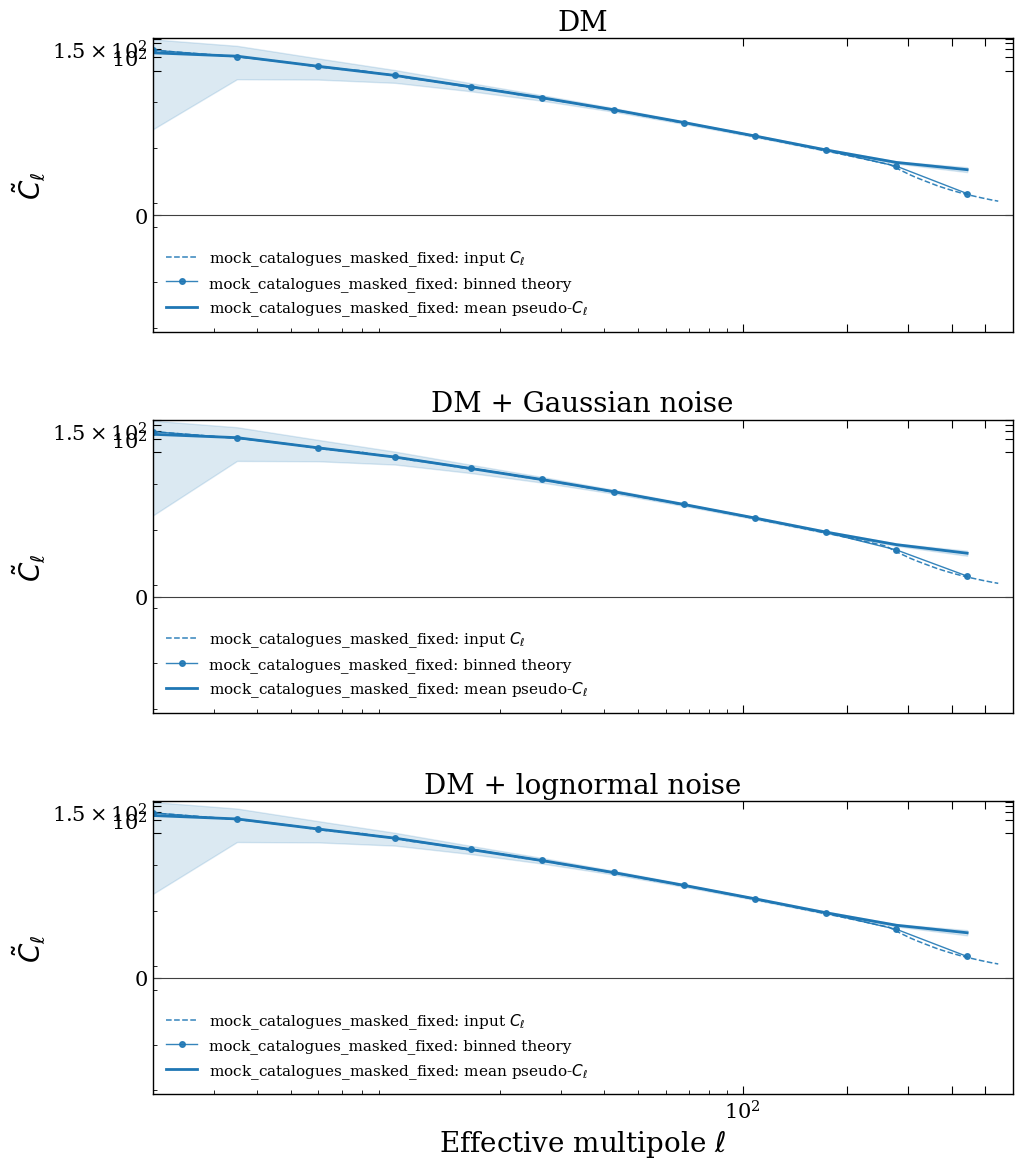

In [1]:
from pathlib import Path

import shutil

import numpy as np

import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator

from astropy.io import fits



fits_paths = [

    Path("/net/home/fohlen13/reischke/Git/pseudo_catcell_covariance_benchmark/output/forecast/mock_catalogues_masked_fixed.fits")

    #Path("/net/home/fohlen13/reischke/Git/pseudo_catcell_covariance_benchmark/output/chime/mock_catalogues_catalog.fits"),

    #Path("/net/home/fohlen13/reischke/Git/pseudo_catcell_covariance_benchmark/output/chime/mock_catalogues_masked_fixed.fits"),

    #Path("/net/home/fohlen13/reischke/Git/pseudo_catcell_covariance_benchmark/output/chime/mock_catalogues_masked_resampled.fits"),

]



fontsi = 15

fontsi2 = 20

n_show_realisations = 0

plt.rcdefaults()

if shutil.which("latex") is not None:

    plt.rc("text", usetex=True)

    plt.rcParams["font.serif"] = ["Computer Modern"]

plt.rc("font", family="serif")

plt.rcParams.update({

    "font.size": fontsi,

    "axes.linewidth": 1.0,

    "xtick.direction": "in",

    "ytick.direction": "in",

    "xtick.major.size": 6,

    "ytick.major.size": 6,

    "xtick.minor.size": 3,

    "ytick.minor.size": 3,

})



def load_pcl_dataset(fits_path):

    with fits.open(fits_path) as hdul:

        pcl_names = sorted(hdu.name for hdu in hdul if hdu.name.startswith("PCL_"))

        if not pcl_names:

            raise ValueError(f"No PCL_* extensions found in {fits_path}")

        if "CELL" not in hdul:

            raise ValueError(f"No CELL extension found in {fits_path}")

        pcl_header = hdul[pcl_names[0]].header

        pcl_tables = [hdul[name].data for name in pcl_names]

        cell_table = hdul["CELL"].data



    ell_eff = np.asarray(pcl_tables[0]["ell_eff"], dtype=float)

    pcl_dm = np.vstack([np.asarray(tab["pcl_dm"], dtype=float) for tab in pcl_tables])

    pcl_dm_gaussian = np.vstack([np.asarray(tab["pcl_dm_gaussian"], dtype=float) for tab in pcl_tables])

    pcl_dm_lognormal = np.vstack([np.asarray(tab["pcl_dm_lognormal"], dtype=float) for tab in pcl_tables])

    theory_ell = np.asarray(cell_table["ell"], dtype=float)

    theory_cl = np.asarray(cell_table["cell"], dtype=float)

    valid_theory = np.isfinite(theory_ell) & np.isfinite(theory_cl) & (theory_ell >= 2)

    theory_ell = theory_ell[valid_theory]

    theory_cl = theory_cl[valid_theory]



    pcl_lmin = int(pcl_header.get("LMIN", max(2, np.floor(ell_eff.min()))))

    pcl_lmax = int(pcl_header.get("LMAX", np.ceil(ell_eff.max())))

    pcl_nbin = int(pcl_header.get("NBIN", len(ell_eff)))

    pcl_edges = np.rint(np.geomspace(pcl_lmin, pcl_lmax + 1, pcl_nbin + 1)).astype(int)

    pcl_edges[0] = pcl_lmin

    pcl_edges[-1] = pcl_lmax + 1

    pcl_edges = np.unique(pcl_edges)



    if len(pcl_edges) - 1 == len(ell_eff):

        theory_binned = np.full(len(ell_eff), np.nan, dtype=float)

        for index, (ell_lo, ell_hi) in enumerate(zip(pcl_edges[:-1], pcl_edges[1:])):

            in_bin = (theory_ell >= ell_lo) & (theory_ell < ell_hi)

            if np.any(in_bin):

                theory_binned[index] = np.mean(theory_cl[in_bin])

    else:

        theory_binned = np.interp(ell_eff, theory_ell, theory_cl, left=np.nan, right=np.nan)



    return {

        "path": Path(fits_path),

        "label": Path(fits_path).stem,

        "ell_eff": ell_eff,

        "theory_ell": theory_ell,

        "theory_cl": theory_cl,

        "theory_binned": theory_binned,

        "series": {

            "DM": pcl_dm,

            "DM + Gaussian noise": pcl_dm_gaussian,

            "DM + lognormal noise": pcl_dm_lognormal,

        },

    }



datasets = [load_pcl_dataset(path) for path in fits_paths]

if not datasets:

    raise ValueError("Provide at least one FITS path in fits_paths.")



series_labels = list(datasets[0]["series"].keys())

for dataset in datasets[1:]:

    if list(dataset["series"].keys()) != series_labels:

        raise ValueError("All input files must contain the same pseudo-C_ell series.")



for dataset in datasets:

    print(f"Read {len(next(iter(dataset['series'].values())))} pseudo-C_ell realisations from {dataset['path'].name}")

    print(f"  Bandpowers: {len(dataset['ell_eff'])}")

    print(f"  ell range: {dataset['ell_eff'].min():.1f} -- {dataset['ell_eff'].max():.1f}")

    print(f"  Theory ell range: {dataset['theory_ell'].min():.0f} -- {dataset['theory_ell'].max():.0f}")



colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))

fig, axes = plt.subplots(len(series_labels), 1, figsize=(10.0, 12.0), sharex=True)

if len(series_labels) == 1:

    axes = [axes]



for ax, label in zip(axes, series_labels):

    y_chunks = []

    for color, dataset in zip(colors, datasets):

        values = dataset["series"][label]

        mean = np.nanmean(values, axis=0)

        std = np.nanstd(values, axis=0)

        ell_eff = dataset["ell_eff"]

        theory_ell = dataset["theory_ell"]

        theory_cl = dataset["theory_cl"]

        theory_binned = dataset["theory_binned"]

        case_label = dataset["label"]



        if n_show_realisations > 0:

            for row in values[: min(n_show_realisations, len(values))]:

                ax.plot(ell_eff, row, color=color, lw=0.6, alpha=0.08)



        ax.plot(

            theory_ell,

            theory_cl,

            color=color,

            lw=1.1,

            ls="--",

            alpha=0.9,

            label=fr"{case_label}: input $C_\ell$",

        )

        ax.plot(

            ell_eff,

            theory_binned,

            color=color,

            marker="o",

            ms=4.0,

            lw=1.0,

            alpha=0.9,

            label=fr"{case_label}: binned theory",

        )

        ax.plot(

            ell_eff,

            mean,

            color=color,

            lw=2.0,

            label=fr"{case_label}: mean pseudo-$C_\ell$",

        )

        ax.fill_between(ell_eff, mean - std, mean + std, color=color, alpha=0.16)

        y_chunks.extend([

            values[np.isfinite(values)],

            mean[np.isfinite(mean)],

            theory_binned[np.isfinite(theory_binned)],

            theory_cl[np.isfinite(theory_cl)],

        ])



    ax.axhline(0.0, color="0.25", lw=0.8)

    y_stack = np.concatenate([chunk for chunk in y_chunks if chunk.size]) if any(chunk.size for chunk in y_chunks) else np.array([1.0])

    y_abs_max = np.nanmax(np.abs(y_stack)) if y_stack.size else 1.0

    linthresh = max(1e-8, 5e-4 * y_abs_max)

    xmax = max(max(dataset["ell_eff"].max(), dataset["theory_ell"].max()) for dataset in datasets)

    xmin = min(dataset["ell_eff"].min() for dataset in datasets)

    ax.set_xscale("log")

    ax.set_yscale("symlog", linthresh=linthresh)

    ax.set_xlim(max(2.0, 0.9 * xmin), 1.1 * xmax)

    ax.set_ylabel(r"$\tilde{C}_\ell$", fontsize=fontsi2)

    ax.set_title(label, fontsize=fontsi2)

    ax.tick_params(labelsize=fontsi, top=True, right=True)

    ax.xaxis.set_major_locator(MaxNLocator(6))

    ax.yaxis.set_major_locator(MaxNLocator(6))

    ax.legend(fontsize=fontsi - 4, frameon=False, loc="best", ncol=1)



axes[-1].set_xlabel(r"Effective multipole $\ell$", fontsize=fontsi2)

fig.subplots_adjust(left=0.12, right=0.98, bottom=0.08, top=0.96, hspace=0.30)

plt.show()


Computed covariance and correlation matrices:
  mock_catalogues_masked_fixed | DM: shape = (12, 12)
  mock_catalogues_masked_fixed | DM + Gaussian noise: shape = (12, 12)
  mock_catalogues_masked_fixed | DM + lognormal noise: shape = (12, 12)


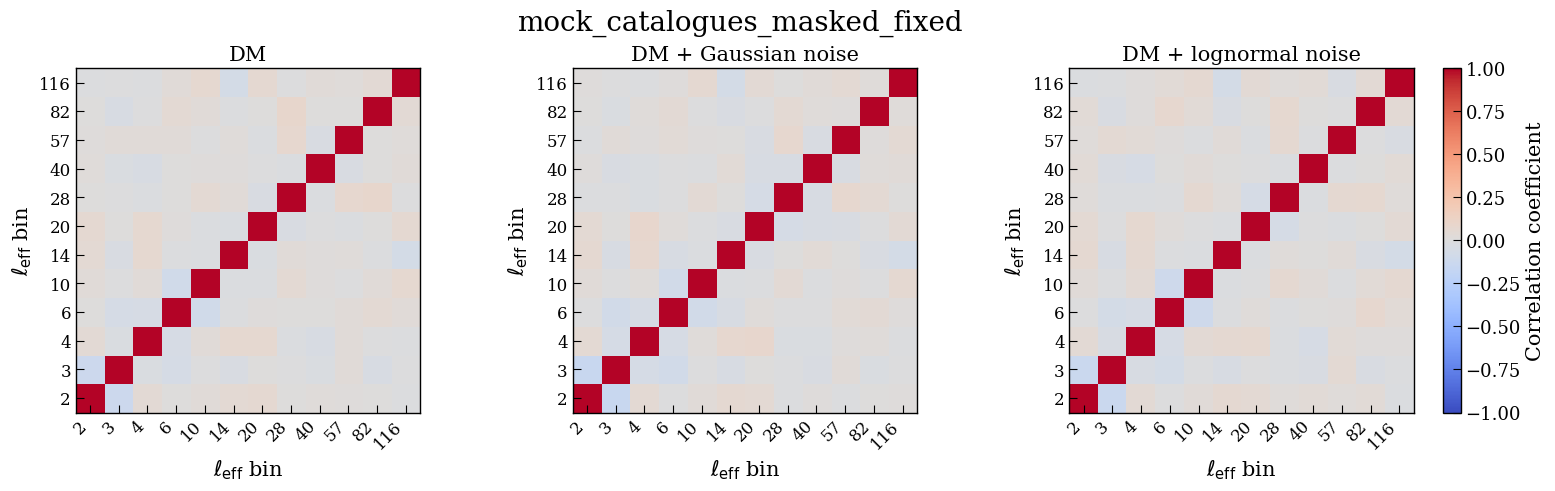

In [2]:
# Covariance and correlation-coefficient matrices for every pseudo-C_ell case and input file.

# Requires Cell 1 to have defined: datasets

if "datasets" not in globals() or not datasets:

    raise ValueError("Run Cell 1 first so 'datasets' is defined.")



covariance_mats = {}

correlation_mats = {}



for dataset in datasets:

    dataset_label = dataset["label"]

    covariance_mats[dataset_label] = {}

    correlation_mats[dataset_label] = {}



    for label, values in dataset["series"].items():

        arr = np.asarray(values, dtype=float)

        cov = np.cov(arr, rowvar=False, ddof=1)

        sigma = np.sqrt(np.diag(cov))

        denom = np.outer(sigma, sigma)

        corr = np.divide(cov, denom, out=np.zeros_like(cov), where=denom > 0)

        covariance_mats[dataset_label][label] = cov

        correlation_mats[dataset_label][label] = corr



print("Computed covariance and correlation matrices:")

for dataset in datasets:

    dataset_label = dataset["label"]

    for label in dataset["series"]:

        shape = covariance_mats[dataset_label][label].shape

        print(f"  {dataset_label} | {label}: shape = {shape}")



series_labels = list(datasets[0]["series"].keys())

for dataset in datasets:

    fig, axes = plt.subplots(1, len(series_labels), figsize=(5.4 * len(series_labels), 4.8), constrained_layout=True)

    if len(series_labels) == 1:

        axes = [axes]



    ell_eff = dataset["ell_eff"]

    dataset_label = dataset["label"]

    im = None



    for ax, label in zip(axes, series_labels):

        corr = correlation_mats[dataset_label][label]

        im = ax.imshow(

            corr,

            origin="lower",

            vmin=-1.0,

            vmax=1.0,

            cmap="coolwarm",

            interpolation="nearest",

        )

        ax.set_title(label, fontsize=fontsi)

        tick_idx = np.arange(len(ell_eff))

        tick_labels = [f"{int(np.rint(x))}" for x in ell_eff]

        ax.set_xticks(tick_idx)

        ax.set_yticks(tick_idx)

        ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=fontsi - 3)

        ax.set_yticklabels(tick_labels, fontsize=fontsi - 3)

        ax.set_xlabel(r"$\ell_{\rm eff}$ bin", fontsize=fontsi)

        ax.set_ylabel(r"$\ell_{\rm eff}$ bin", fontsize=fontsi)



    cbar = fig.colorbar(im, ax=np.atleast_1d(axes).ravel().tolist(), fraction=0.03, pad=0.02)

    cbar.set_label("Correlation coefficient", fontsize=fontsi)

    cbar.ax.tick_params(labelsize=fontsi - 2)

    fig.suptitle(dataset_label, fontsize=fontsi2)

    plt.show()


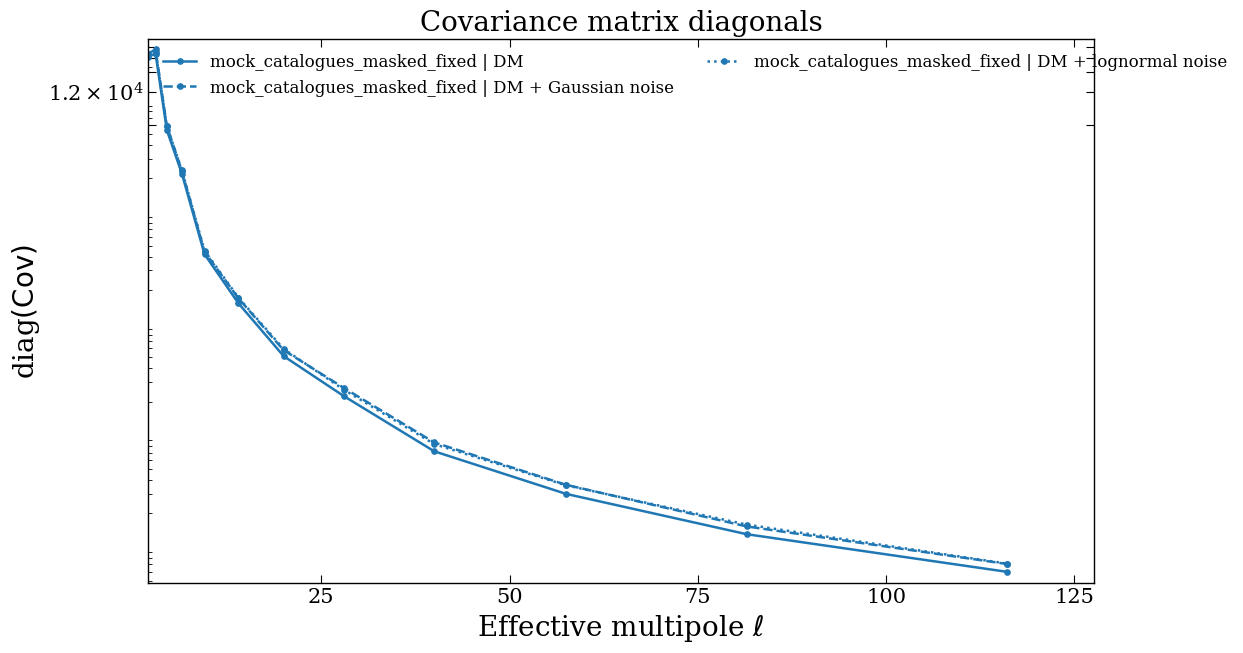

In [3]:
# Diagonals of the covariance matrices on a single plot.

# Requires Cell 2 to have defined: covariance_mats and datasets

if "covariance_mats" not in globals() or "datasets" not in globals() or not datasets:

    raise ValueError("Run Cells 1 and 2 first so 'covariance_mats' and 'datasets' are defined.")



series_labels = list(datasets[0]["series"].keys())

colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))

line_styles = ["-", "--", ":", "-."]



fig, ax = plt.subplots(figsize=(11.0, 6.8))

y_chunks = []



for color, dataset in zip(colors, datasets):

    dataset_label = dataset["label"]

    ell_eff = dataset["ell_eff"]



    for index, label in enumerate(series_labels):

        cov_diag = np.diag(covariance_mats[dataset_label][label])

        ax.plot(

            ell_eff,

            cov_diag,

            marker="o",

            ms=3.8,

            lw=1.8,

            color=color,

            ls=line_styles[index % len(line_styles)],

            label=f"{dataset_label} | {label}",

        )

        finite = cov_diag[np.isfinite(cov_diag)]

        if finite.size:

            y_chunks.append(finite)



y_stack = np.concatenate(y_chunks) if y_chunks else np.array([1.0])

y_min = np.nanmin(y_stack)

y_max = np.nanmax(y_stack)

if y_min > 0:

    ax.set_yscale("log")

    ax.set_ylim(0.8 * y_min, 1.25 * y_max)

else:

    y_abs_max = np.nanmax(np.abs(y_stack)) if y_stack.size else 1.0

    linthresh = max(1e-12, 1e-4 * y_abs_max)

    ax.set_yscale("symlog", linthresh=linthresh)



xmin = min(dataset["ell_eff"].min() for dataset in datasets)

xmax = max(dataset["ell_eff"].max() for dataset in datasets)

#ax.set_xscale("log")

ax.set_xlim(max(2.0, 0.9 * xmin), 1.1 * xmax)

ax.set_xlabel(r"Effective multipole $\ell$", fontsize=fontsi2)

ax.set_ylabel(r"diag$\left(\mathrm{Cov}\right)$", fontsize=fontsi2)

ax.set_title("Covariance matrix diagonals", fontsize=fontsi2)

ax.tick_params(labelsize=fontsi, top=True, right=True)

ax.xaxis.set_major_locator(MaxNLocator(6))

ax.yaxis.set_major_locator(MaxNLocator(6))

ax.legend(fontsize=fontsi - 3, frameon=False, loc="best", ncol=2)

fig.subplots_adjust(left=0.12, right=0.98, bottom=0.12, top=0.92)

plt.show()


Total SNR from mean signal and covariance:
  mock_catalogues_masked_fixed | DM: SNR = 6.8052
  mock_catalogues_masked_fixed | DM + Gaussian noise: SNR = 6.5204
  mock_catalogues_masked_fixed | DM + lognormal noise: SNR = 6.3484


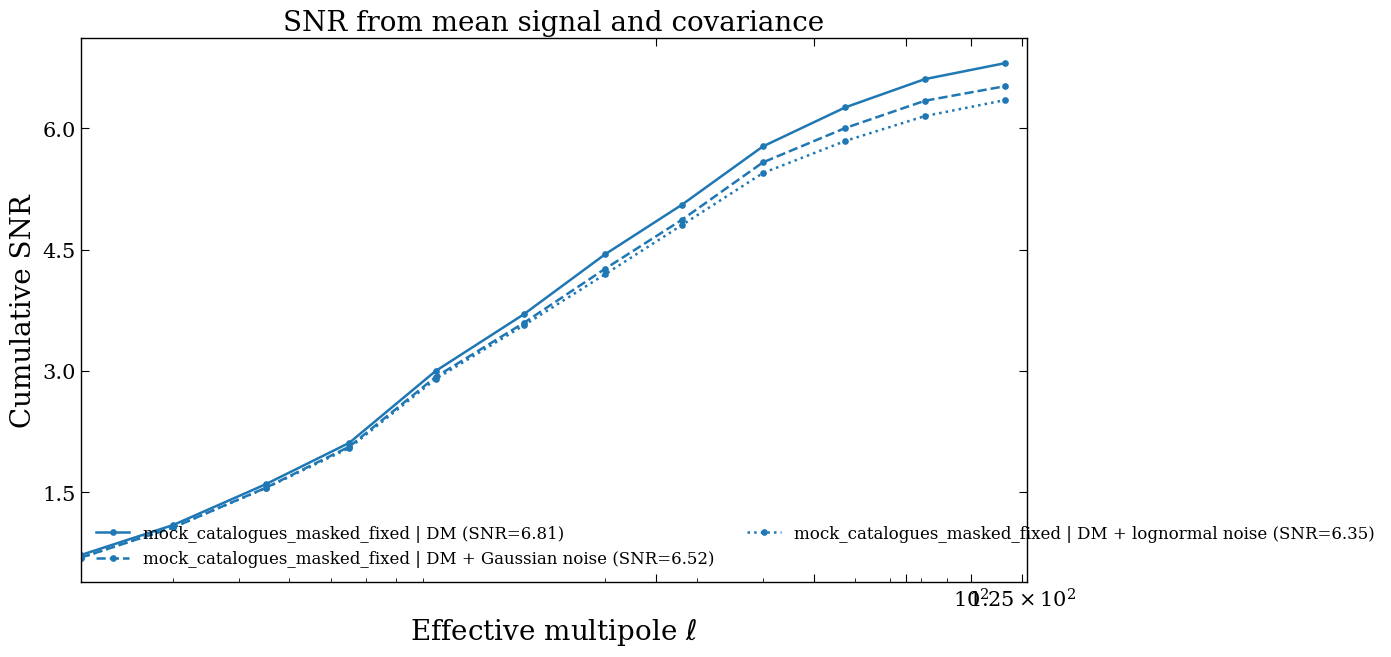

In [4]:
# Signal-to-noise ratio from the mean signal and covariance.

# Requires Cells 1 and 2 to have defined: datasets and covariance_mats

if "covariance_mats" not in globals() or "datasets" not in globals() or not datasets:

    raise ValueError("Run Cells 1 and 2 first so 'covariance_mats' and 'datasets' are defined.")



series_labels = list(datasets[0]["series"].keys())

colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))

line_styles = ["-", "--", ":", "-."]

snr_results = {}



def compute_total_snr(signal_vec, cov_mat):

    cov_use = 0.5 * (cov_mat + cov_mat.T)

    inv_cov = np.linalg.pinv(cov_use, hermitian=True)

    snr_sq = float(signal_vec @ inv_cov @ signal_vec)

    return np.sqrt(max(snr_sq, 0.0))



fig, ax = plt.subplots(figsize=(11.0, 6.8))



for color, dataset in zip(colors, datasets):

    dataset_label = dataset["label"]

    ell_eff = np.asarray(dataset["ell_eff"], dtype=float)

    snr_results[dataset_label] = {}



    for index, label in enumerate(series_labels):

        values = np.asarray(dataset["series"][label], dtype=float)

        mean_signal = np.nanmean(values, axis=0)

        cov_mat = np.asarray(covariance_mats[dataset_label][label], dtype=float)

        valid = np.isfinite(mean_signal) & np.all(np.isfinite(cov_mat), axis=0) & np.all(np.isfinite(cov_mat), axis=1)

        if np.count_nonzero(valid) == 0:

            snr_results[dataset_label][label] = {"total": np.nan, "cumulative": np.full_like(mean_signal, np.nan, dtype=float)}

            continue



        mean_use = mean_signal[valid]

        cov_use = cov_mat[np.ix_(valid, valid)]

        total_snr = compute_total_snr(mean_use, cov_use)

        cumulative_snr = np.full_like(mean_signal, np.nan, dtype=float)



        valid_indices = np.flatnonzero(valid)

        for stop_idx, _ in enumerate(valid_indices, start=1):

            mean_partial = mean_use[:stop_idx]

            cov_partial = cov_use[:stop_idx, :stop_idx]

            cumulative_snr[valid_indices[stop_idx - 1]] = compute_total_snr(mean_partial, cov_partial)



        snr_results[dataset_label][label] = {

            "total": total_snr,

            "cumulative": cumulative_snr,

        }



        ax.plot(

            ell_eff,

            cumulative_snr,

            color=color,

            ls=line_styles[index % len(line_styles)],

            lw=1.8,

            marker="o",

            ms=3.8,

            label=f"{dataset_label} | {label} (SNR={total_snr:.2f})",

        )



print("Total SNR from mean signal and covariance:")

for dataset_label, dataset_result in snr_results.items():

    for label, result in dataset_result.items():

        print(f"  {dataset_label} | {label}: SNR = {result['total']:.4f}")



xmin = min(dataset["ell_eff"].min() for dataset in datasets)

xmax = max(dataset["ell_eff"].max() for dataset in datasets)

ax.set_xlim(max(2.0, 0.9 * xmin), 1.1 * xmax)

ax.set_xscale("log")

ax.set_xlabel(r"Effective multipole $\ell$", fontsize=fontsi2)

ax.set_ylabel("Cumulative SNR", fontsize=fontsi2)

ax.set_title("SNR from mean signal and covariance", fontsize=fontsi2)

ax.tick_params(labelsize=fontsi, top=True, right=True)

ax.xaxis.set_major_locator(MaxNLocator(6))

ax.yaxis.set_major_locator(MaxNLocator(6))

ax.legend(fontsize=fontsi - 3, frameon=False, loc="best", ncol=2)

fig.subplots_adjust(left=0.12, right=0.98, bottom=0.12, top=0.92)

plt.show()
